Dataset Description

Dataset: Breast Cancer Wisconsin (Diagnostic)

The dataset consists of features computed from breast mass images.
It is commonly used to evaluate classification algorithms.

Samples: 569

Features: 30 numerical features

Classes:

0 → Malignant

1 → Benign



In [ ]:
#Install Required Libraries (Colab Only)
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
from logging import WARNING
#Import Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset & preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Boosting models
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report




In [ ]:
#Load and Explore Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


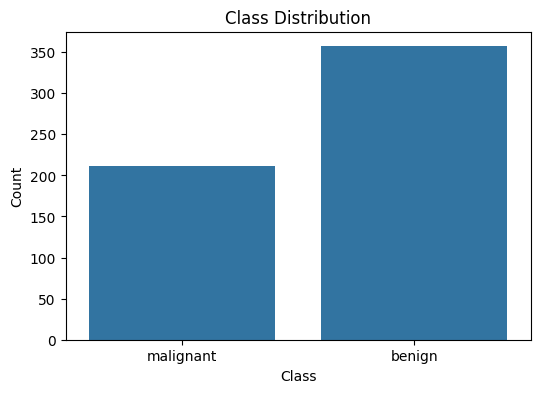

In [ ]:
#Class Distribution Visualization
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.xticks([0,1], data.target_names)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
#Preprocessing & Train-Test Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Define Boosting Models
models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, random_state=42
    ),

    "Stochastic Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, subsample=0.8, random_state=42
    ),

    "Histogram GB (HPBoost-style)": HistGradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        eval_metric='logloss', use_label_encoder=False, random_state=42
    ),

    "LightGBM": LGBMClassifier(random_state=42),

    "CatBoost": CatBoostClassifier(
        verbose=0, random_state=42
    )
}

In [ ]:
#Train Models & Collect Metrics
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4544
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Results Table
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,AdaBoost,0.964912,0.947368,1.000000,0.972973
1,Gradient Boosting,0.956140,0.946667,0.986111,0.965986
2,Stochastic Gradient Boosting,0.956140,0.946667,0.986111,0.965986
3,Histogram GB (HPBoost-style),0.973684,0.960000,1.000000,0.979592
4,XGBoost,0.956140,0.946667,0.986111,0.965986
5,LightGBM,0.964912,0.959459,0.986111,0.972603
6,CatBoost,0.956140,0.946667,0.986111,0.965986


<Figure size 1200x600 with 0 Axes>

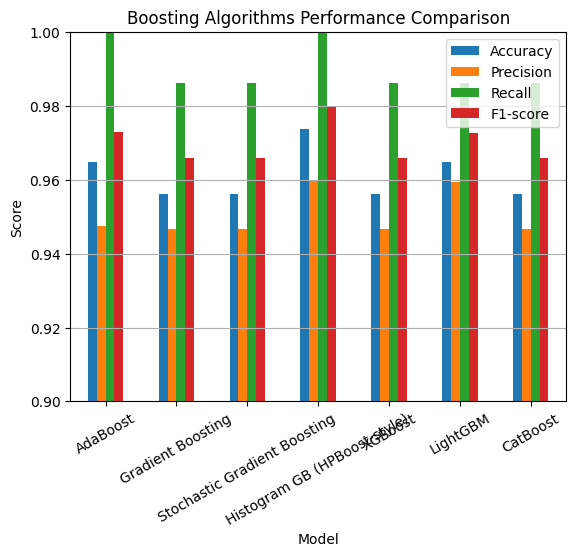

In [ ]:
#Performance Comparison Visualization
plt.figure(figsize=(12,6))
results_df.set_index("Model").plot(kind="bar")
plt.ylim(0.9,1)
plt.title("Boosting Algorithms Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

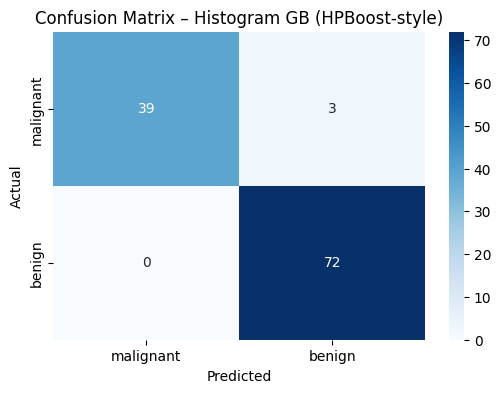

In [ ]:
#Confusion Matrix for Best Model
best_model_name = results_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Detailed Classification Report
print(f"Classification Report for {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

Classification Report for Histogram GB (HPBoost-style)

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Discussion of Results

Discussion:
All boosting algorithms achieved strong classification performance.
Advanced boosting techniques such as XGBoost, LightGBM, and CatBoost slightly outperformed classical methods due to optimized tree growth, regularization, and parallel processing.

CatBoost demonstrated excellent stability, while LightGBM provided fast training.
AdaBoost, although simpler, was more sensitive to noise.

Boosting algorithms remain among the most powerful techniques for structured data.